# CCO10: Re-Pass CCO08

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import scipy
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import ListedColormap
import anndata as ad

In [2]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO08"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO10"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [4]:
samples = ['ALL', 'VO', 'HO', 'ReAgg-CM', 'Fus-HO', 'VasHO']
samples_old = ['ALL','VO','HO','CA','VHO','VCO']
cell_types = ['CM','EC','EP','PVSC','UN']

colormap_cell_types = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "EP": (141/255, 160/255, 203/255),
    "PVSC": (255/255, 210/255, 60/255),
    "UN": (190/255, 190/255, 190/255),
}

colormap_subclusters = {
    "CM_1": (30/255, 120/255, 30/255),
    "CM_2": (150/255, 230/255, 150/255),
    "CM_3": (15/255, 80/255, 15/255),
    "CM_4": (90/255, 190/255, 90/255),
    
    "EC_1": (255/255, 200/255, 230/255),
    "EC_2": (230/255, 80/255, 160/255),
    "EC_3": (180/255, 30/255, 120/255),
    
    "PVSC_1": (255/255, 250/255, 200/255),
    "PVSC_2": (255/255, 245/255, 175/255),
    "PVSC_3": (255/255, 240/255, 150/255),
    "PVSC_4": (255/255, 235/255, 125/255),
    "PVSC_5": (255/255, 230/255, 100/255),
    "PVSC_6": (255/255, 220/255, 75/255),
    "PVSC_7": (255/255, 210/255, 50/255),
    "PVSC_8": (255/255, 200/255, 25/255),
    "PVSC_9": (240/255, 180/255, 10/255),
    "PVSC_10": (220/255, 160/255, 0/255),

    "EP": (141/255, 160/255, 203/255),

    "UN": (190/255, 190/255, 190/255),
}

colormap_cpdb = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "EP": (141/255, 160/255, 203/255),
    "PVSC": (255/255, 235/255, 125/255),
    "FB": (240/255, 180/255, 20/255),
    "SM": (220/255, 160/255, 30/255),
    "UN": (190/255, 190/255, 190/255),
    "OTH": (170/255, 170/255, 170/255),
}

In [12]:
os.system(f"mkdir -p {WORK_DIR}/adata")

# os.system(f"rm -r {WORK_DIR}/dotplot; mkdir -p {WORK_DIR}/dotplot")
# os.system(f"rm -r {WORK_DIR}/UMAP; mkdir -p {WORK_DIR}/UMAP")
# os.system(f"rm -r {WORK_DIR}/distribution; mkdir -p {WORK_DIR}/distribution")

0

# 0. Prepare data

In [29]:
samples_map = {
    'ALL': 'ALL', 
    'VO': 'VO', 
    'HO': 'HO', 
    'CA': 'ReAgg-CM', 
    'VHO': 'Fus-HO', 
    'VCO': 'VasHO'
}

In [50]:
# os.system(f"ln -s {PREV_DIR}/adata/cell_type_labelled {WORK_DIR}/adata/")

In [31]:
os.system(f"rm -r {WORK_DIR}/adata/cell_type_subclustered")
os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_subclustered")

for f in glob.glob(f"{PREV_DIR}/adata/cell_type_subclustered/*.h5ad"):
    celltype = f.split("/")[-1].strip(".h5ad")
    adata = sc.read_h5ad(f)
    
    if celltype == "MU":
        adata.obs["cell_type_subcluster"] = adata.obs["cell_type_subcluster"].map({
            'FB': 'PVSC_9', 
            'PR_1': 'PVSC_1', 
            'PR_2': 'PVSC_2', 
            'PR_3': 'PVSC_3', 
            'PR_4': 'PVSC_4', 
            'PR_5': 'PVSC_5', 
            'PR_6': 'PVSC_6', 
            'PR_7': 'PVSC_7', 
            'PR_8': 'PVSC_8', 
            'SM': 'PVSC_10'
        })
        adata.obs["cell_type_subcluster"] = adata.obs["cell_type_subcluster"].astype("category")
        adata.obs["cell_type"] = adata.obs["cell_type"].map({"MU": "PVSC"})
        adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
        celltype = "PVSC"
        
    adata.obs['batch'] = adata.obs['batch'].map(samples_map)
    adata.obs['batch'] = adata.obs['batch'].astype("category")
    
    adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{celltype}.h5ad")

In [46]:
os.system(f"rm -r {WORK_DIR}/adata/sample_recollect")
os.system(f"mkdir -p {WORK_DIR}/adata/sample_recollect")

for i, f in enumerate(glob.glob(f"{WORK_DIR}/adata/cell_type_subclustered/*.h5ad")):
    if i == 0:
        adata_full = sc.read_h5ad(f)
    else:
        adata_full = sc.concat([adata_full, sc.read_h5ad(f)])
adata_full.write(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

for batch in adata_full.obs["batch"].unique():
    adata_full[adata_full.obs["batch"] == batch].write(f"{WORK_DIR}/adata/sample_recollect/{batch}.h5ad")

# 1. Inspect the Leiden clustered data

In [13]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")

In [14]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

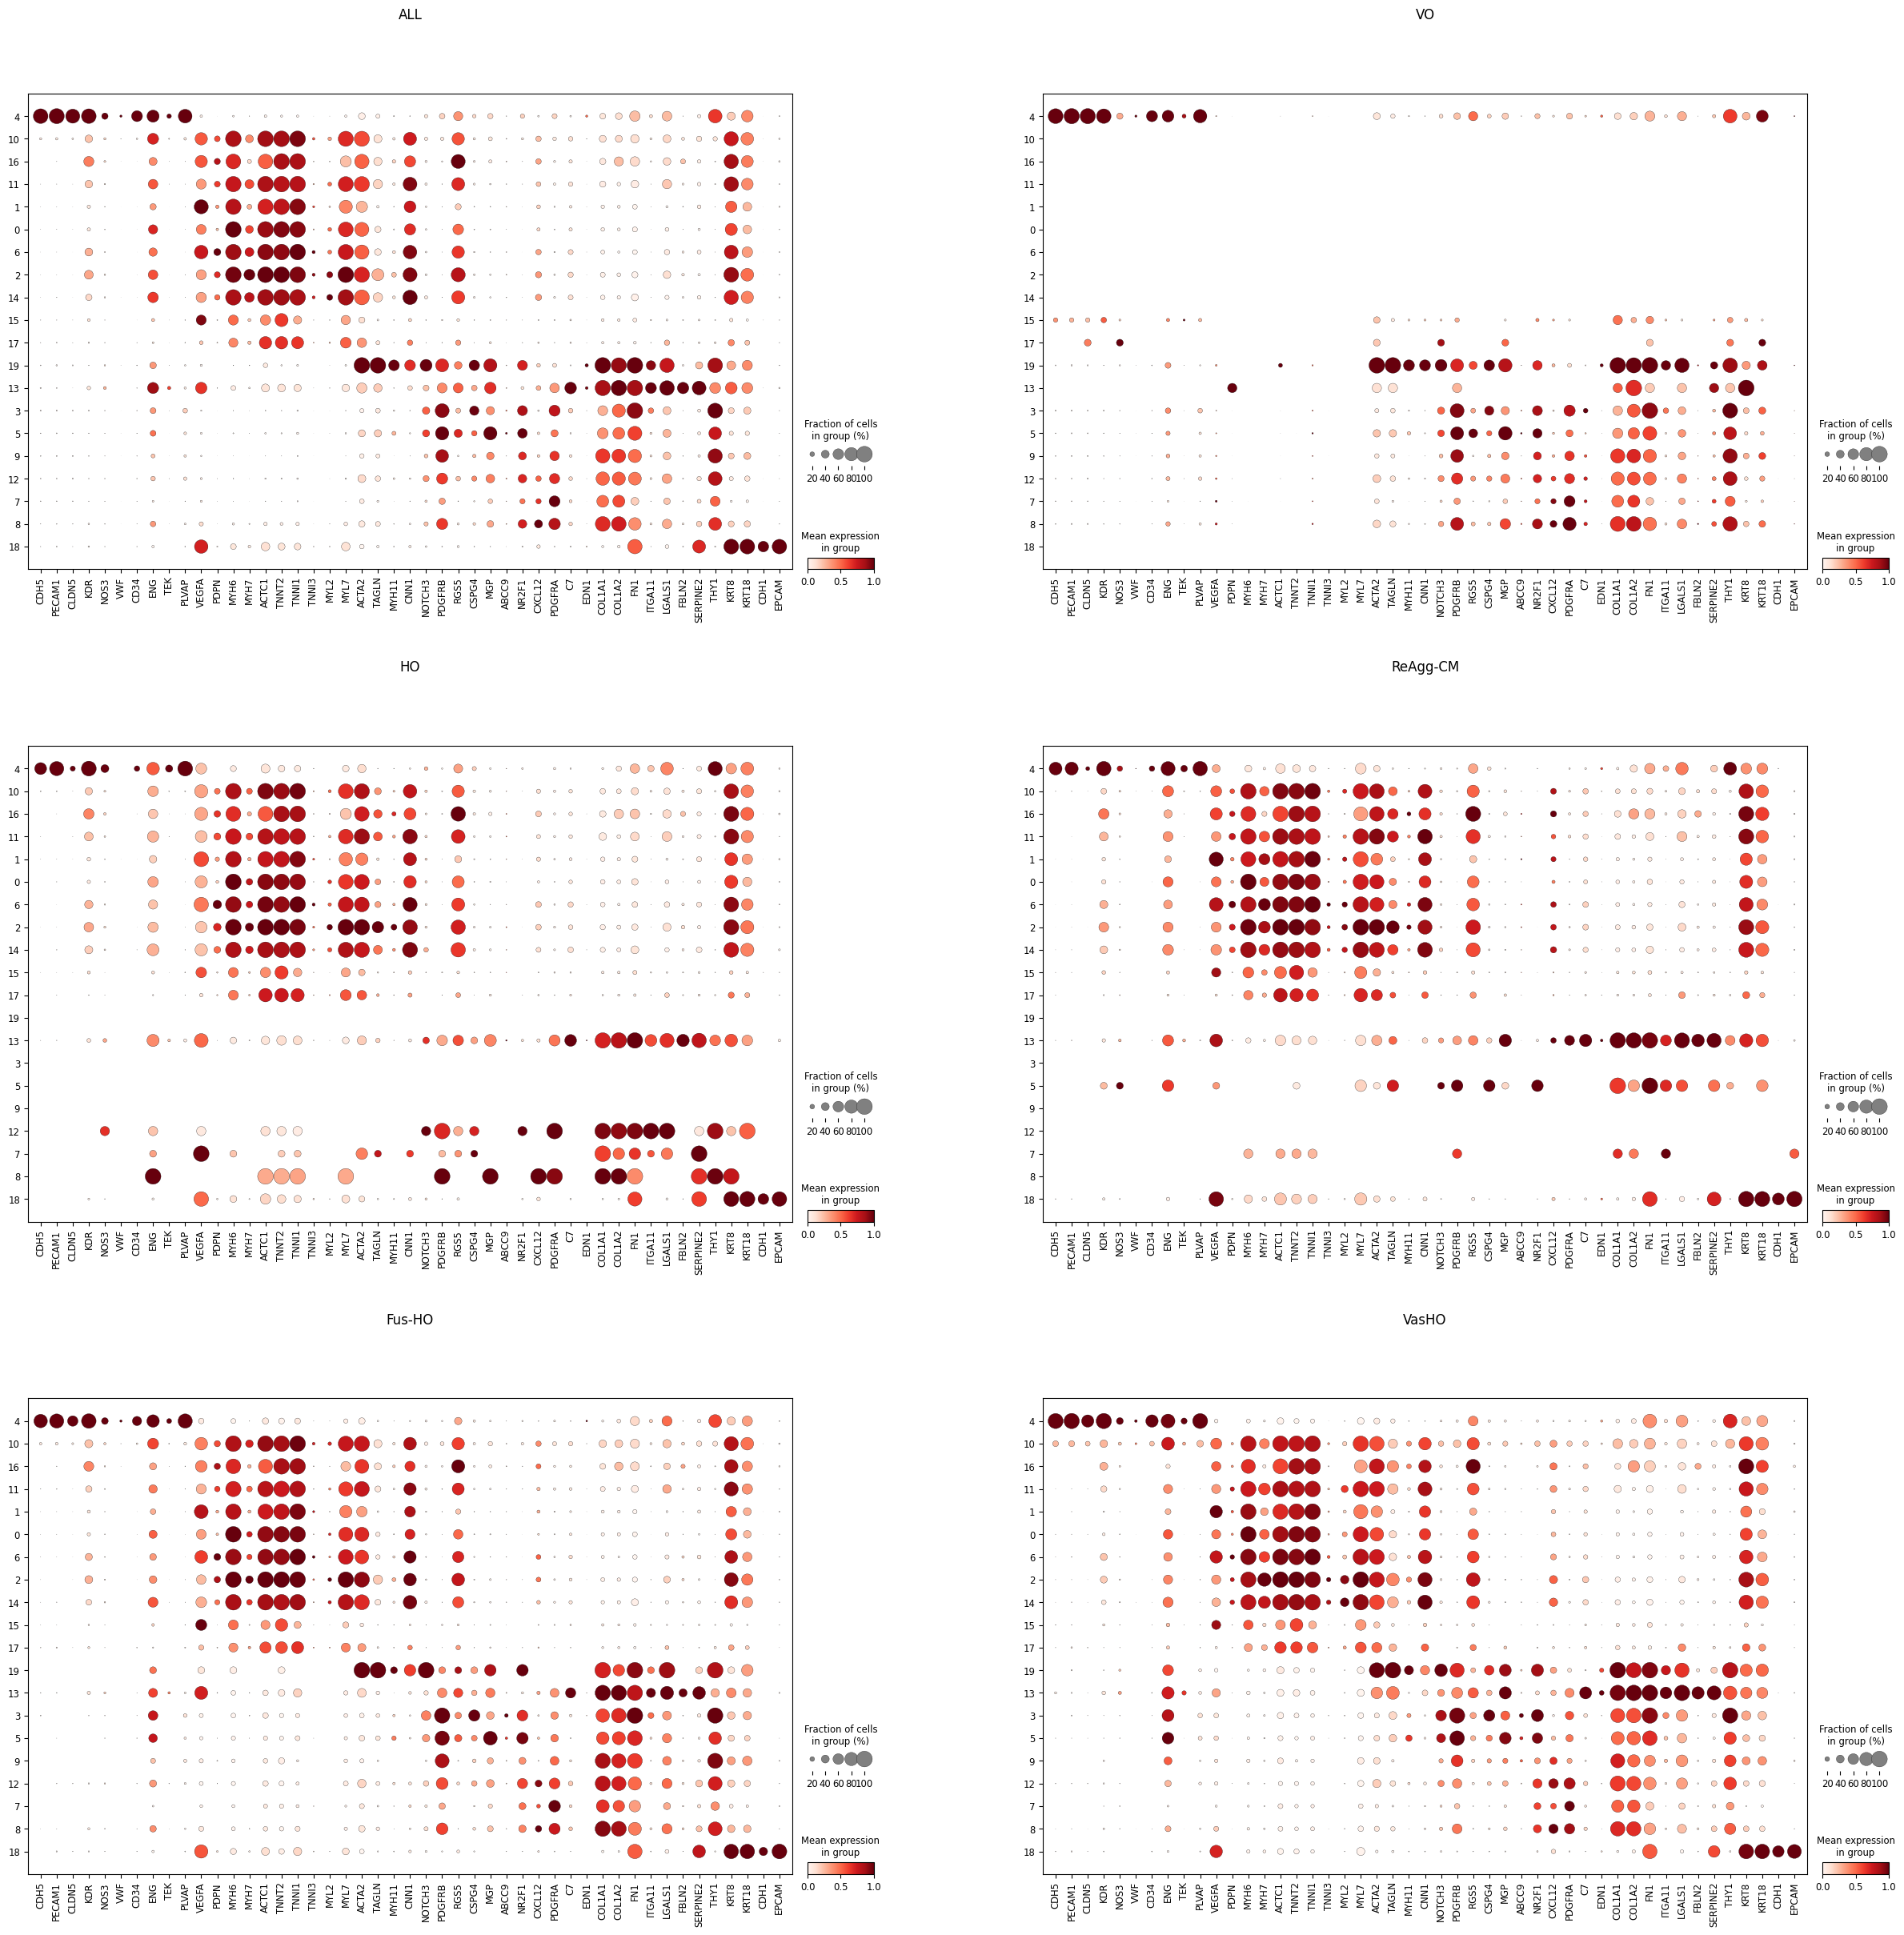

In [15]:
import warnings
warnings.filterwarnings("ignore")

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

cluster_order = [4, 10, 16, 11, 1, 0, 6, 2, 14, 15, 17, 19, 13, 3, 5, 9, 12, 7, 8, 18]

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples_old[i]]
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, 
                  marker_dict, 
                  categories_order=cluster_order,
                  groupby="leiden", 
                  standard_scale="var", 
                  ax=axs[i], 
                  title=sample, 
                  show=False)
    
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.png')
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.svg')
plt.show()

In [16]:
celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'MU',
    '4': 'EC',
    '5': 'MU',
    '6': 'CM',
    '7': 'MU',
    '8': 'MU',
    '9': 'MU',
    '10': 'CM',
    '11': 'CM',
    '12': 'MU',
    '13': 'MU',
    '14': 'CM',
    '15': 'UN',
    '16': 'CM',
    '17': 'UN',
    '18': 'EP',
    '19': 'MU',
}

CM_order = [10, 16, 11, 1, 0, 6, 2, 14]
CM_color_min = (150/255, 230/255, 150/255)
CM_color_max = (15/255, 80/255, 15/255)

# MU_order = [13, 19, 3, 5, 9, 12, 7, 8]
MU_order = [19, 13, 8, 7, 12, 9, 5, 3]
MU_color_min = (240/255, 180/255, 20/255)
MU_color_max = (255/255, 250/255, 200/255)

def getColor(ld):
    ct = celltypes_dict[str(ld)]
    if ct in ("EP", "EC"):
        return colormap_cell_types[ct]
    elif ct == "CM":
        idx = CM_order.index(ld)
        clr = []
        for i in range(0, 3):
            clr.append(CM_color_min[i] + (CM_color_max[i]-CM_color_min[i]) / (len(CM_order)-1) * idx)
        return tuple(clr)
    elif ct == "MU":
        idx = MU_order.index(ld)
        clr = []
        for i in range(0, 3):
            clr.append(MU_color_min[i] + (MU_color_max[i]-MU_color_min[i]) / (len(MU_order)-1) * idx)
        return tuple(clr)
    else:
        clr = list(colormap_cell_types[ct])
        for i in range(0, len(clr)):
            np.random.seed(ld)
            clr[i] += (np.random.random() - 0.5) / 4
            if clr[i] > 1:
                clr[i] = 1
            elif clr[i] < 0:
                clr[i] = 0
        return tuple(clr)

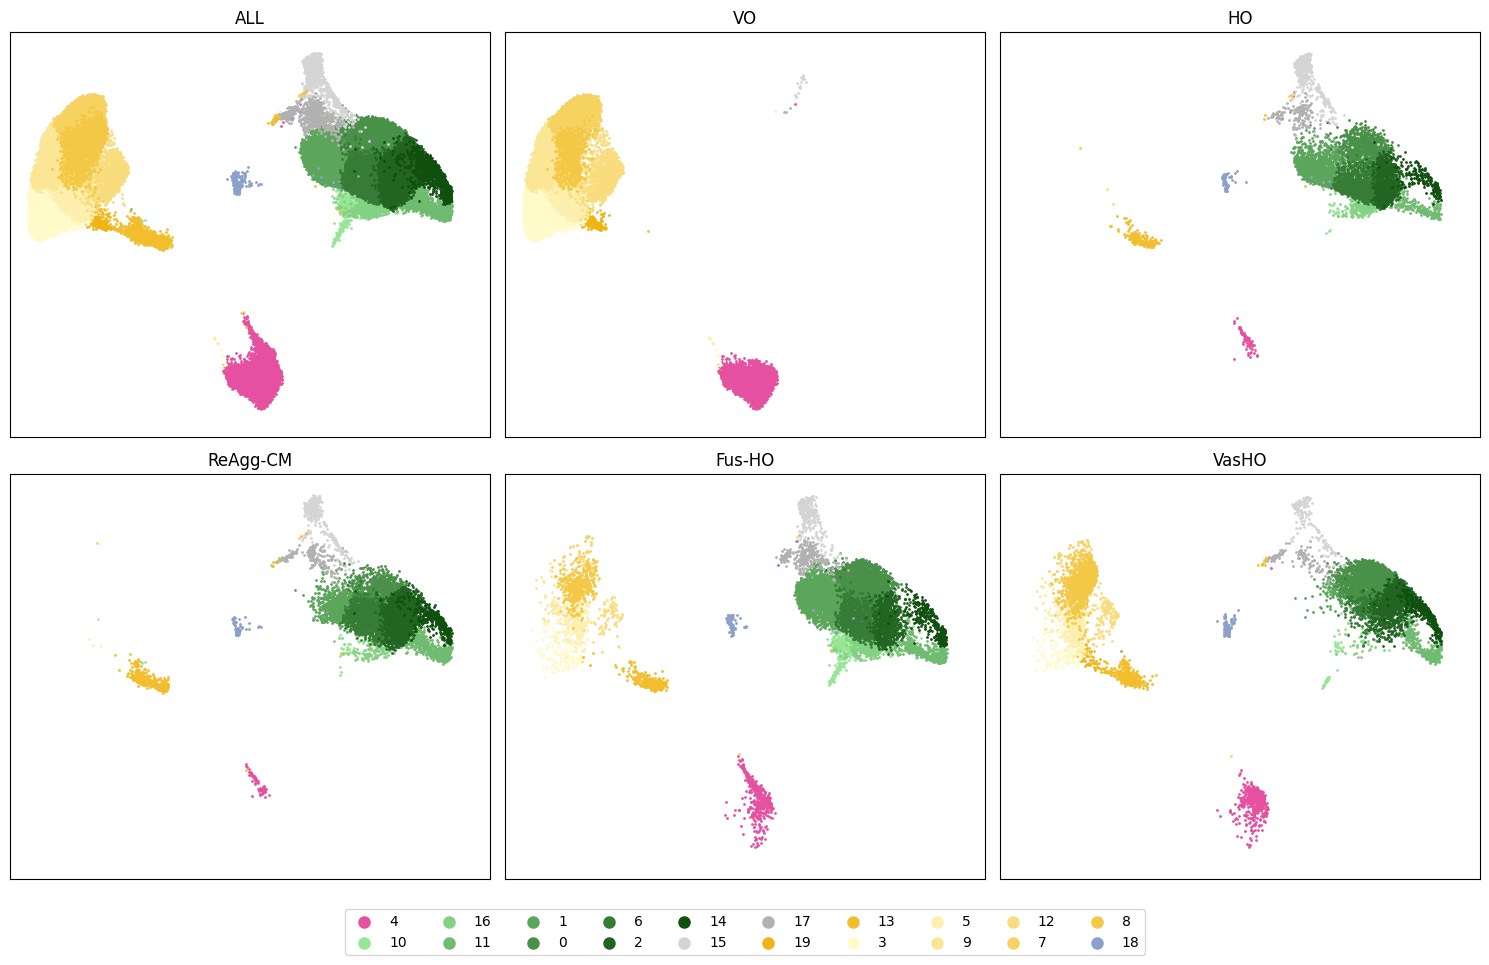

In [17]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples_old[i]]
    
    # for j, ld in enumerate(adata_all.obs["leiden"].unique().sort_values()):
    for j, ld in enumerate(cluster_order):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 1], 
            label=ld, 
            color=getColor(ld), 
            s=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.075)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.svg', bbox_inches="tight")
plt.show()

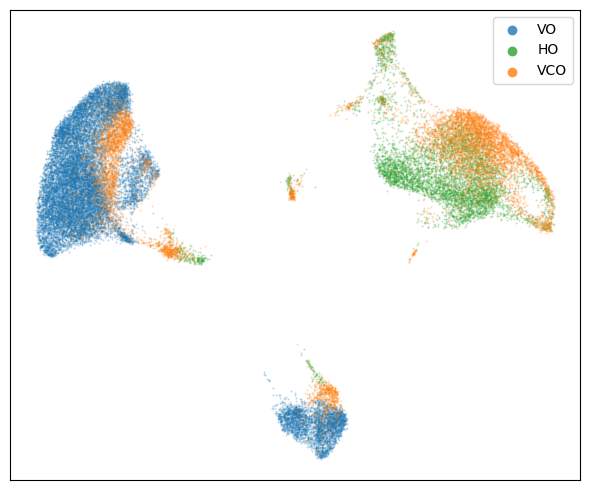

In [18]:
bc1 = "VO"
bc2 = "HO"
bc3 = "VCO"

adata_vo = adata_all[adata_all.obs['batch'] == bc1]
adata_ho = adata_all[adata_all.obs['batch'] == bc2]
adata_vco = adata_all[adata_all.obs['batch'] == bc3]

fig, ax = plt.subplots(1, 1, figsize=(6,5))
colors = plt.get_cmap('tab10').colors

ax.scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=2, alpha=0.3, linewidths=0)
ax.scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=2, alpha=0.3, linewidths=0)
ax.scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=2, alpha=0.3, linewidths=0)
# ax.set_title(f"{bc1} + {bc2}")
leg = ax.legend(markerscale=5)
ax.set_xticks([])
ax.set_yticks([])

for lh in leg.legend_handles:
    lh.set_alpha(0.8)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
plt.show()

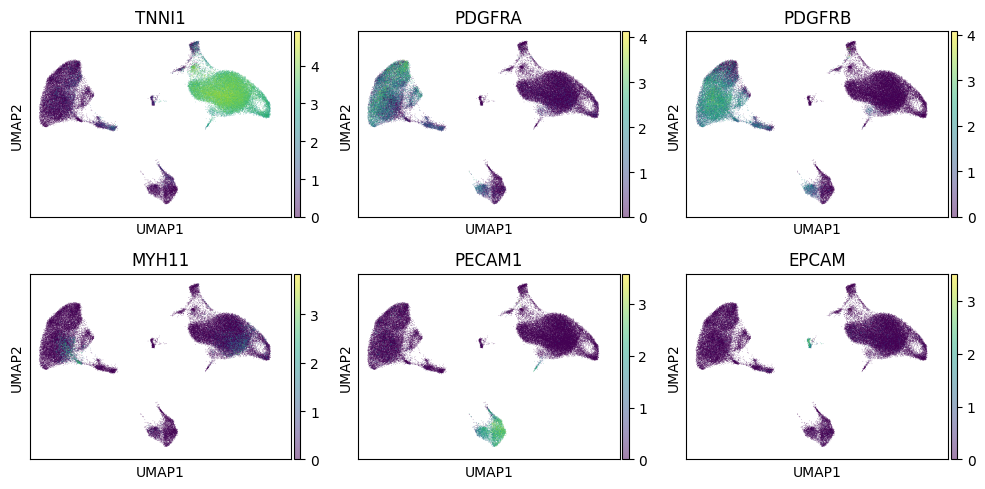

In [19]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs = axs.flatten()

for i, gene in enumerate(('TNNI1','PDGFRA','PDGFRB','MYH11','PECAM1','EPCAM')):
    sc.pl.umap(adata_all, color=gene, show=False, ax=axs[i], title=gene, s=1, alpha=0.5)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/marker_color.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/marker_color.complete.svg', bbox_inches="tight")
plt.show()

# 2. Celltype split and recluster

## 2.1 CM

In [20]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

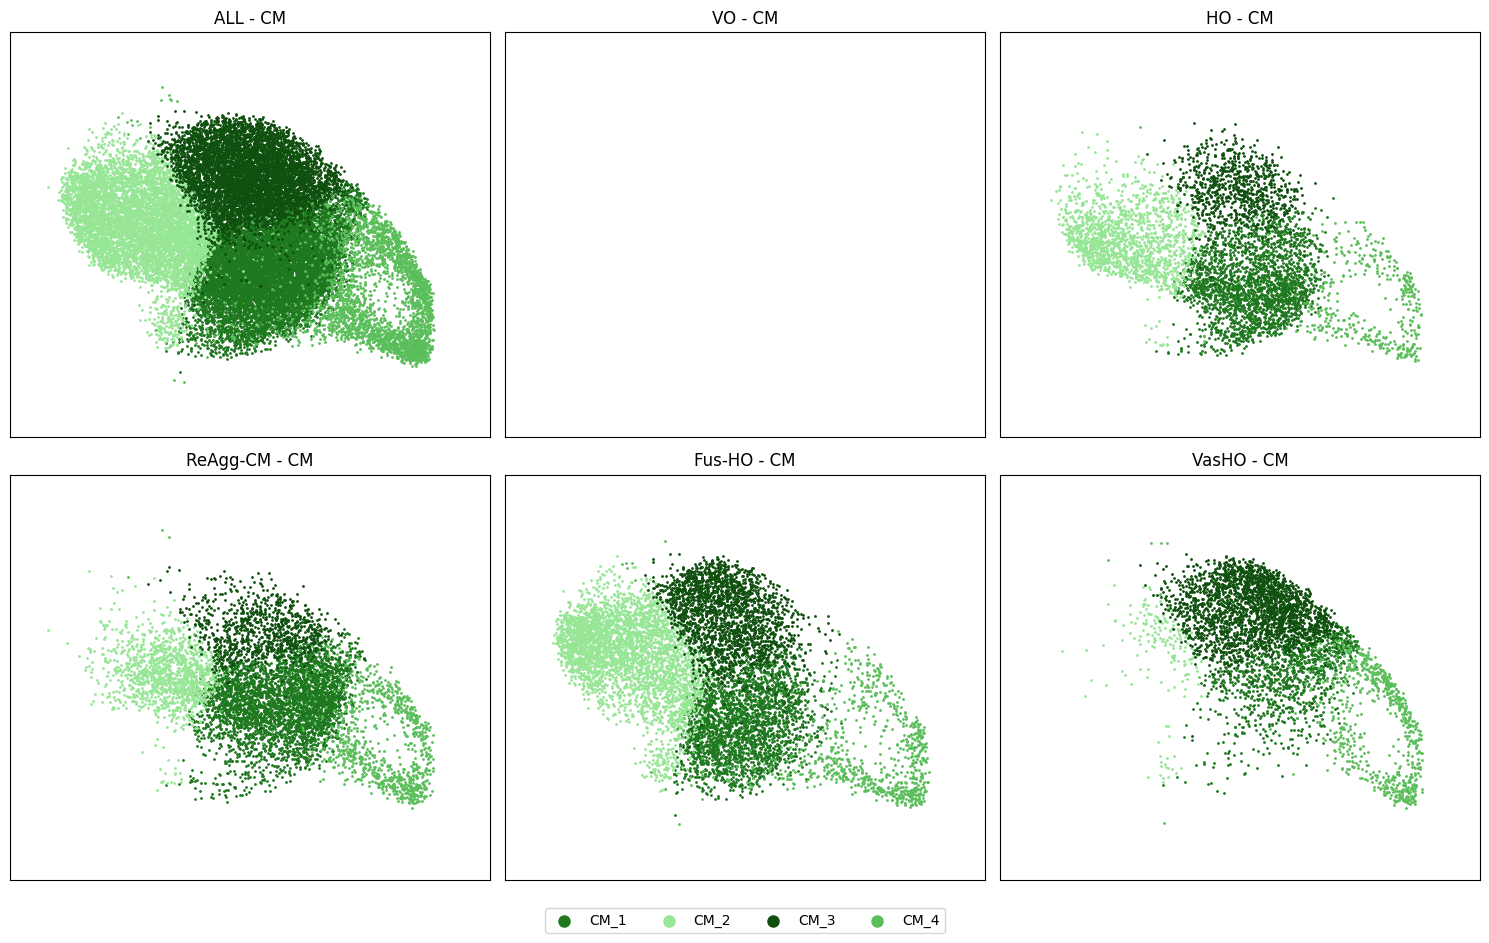

In [21]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([7, 20])
    ax.set_ylim([5, 15])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

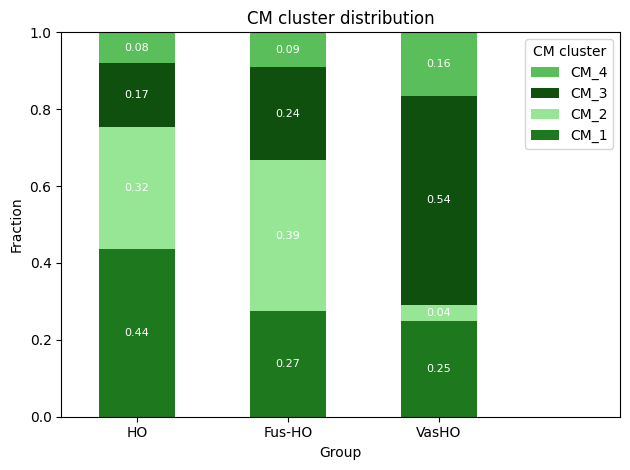

In [22]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'ReAgg-CM' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

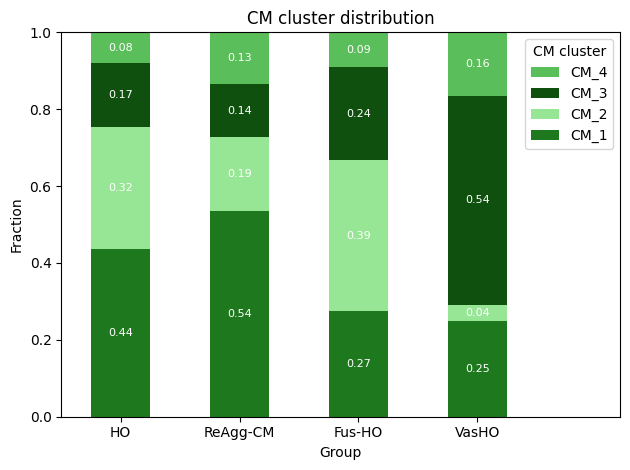

In [23]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

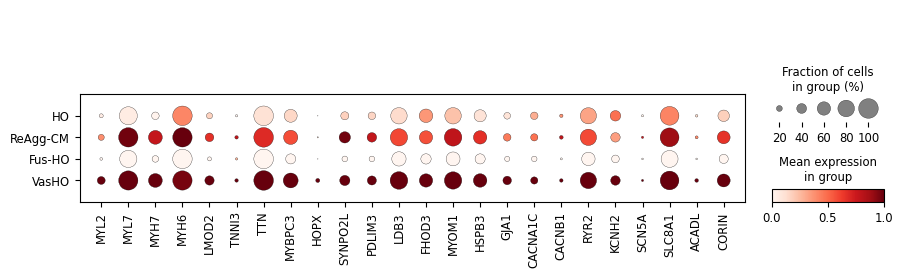

In [24]:
marker_dict = ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 
               'HOPX', 'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SCN5A', 'SLC8A1', 
               'ACADL', 'CORIN']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("VO")

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.2 EC

In [25]:
ct = "EC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

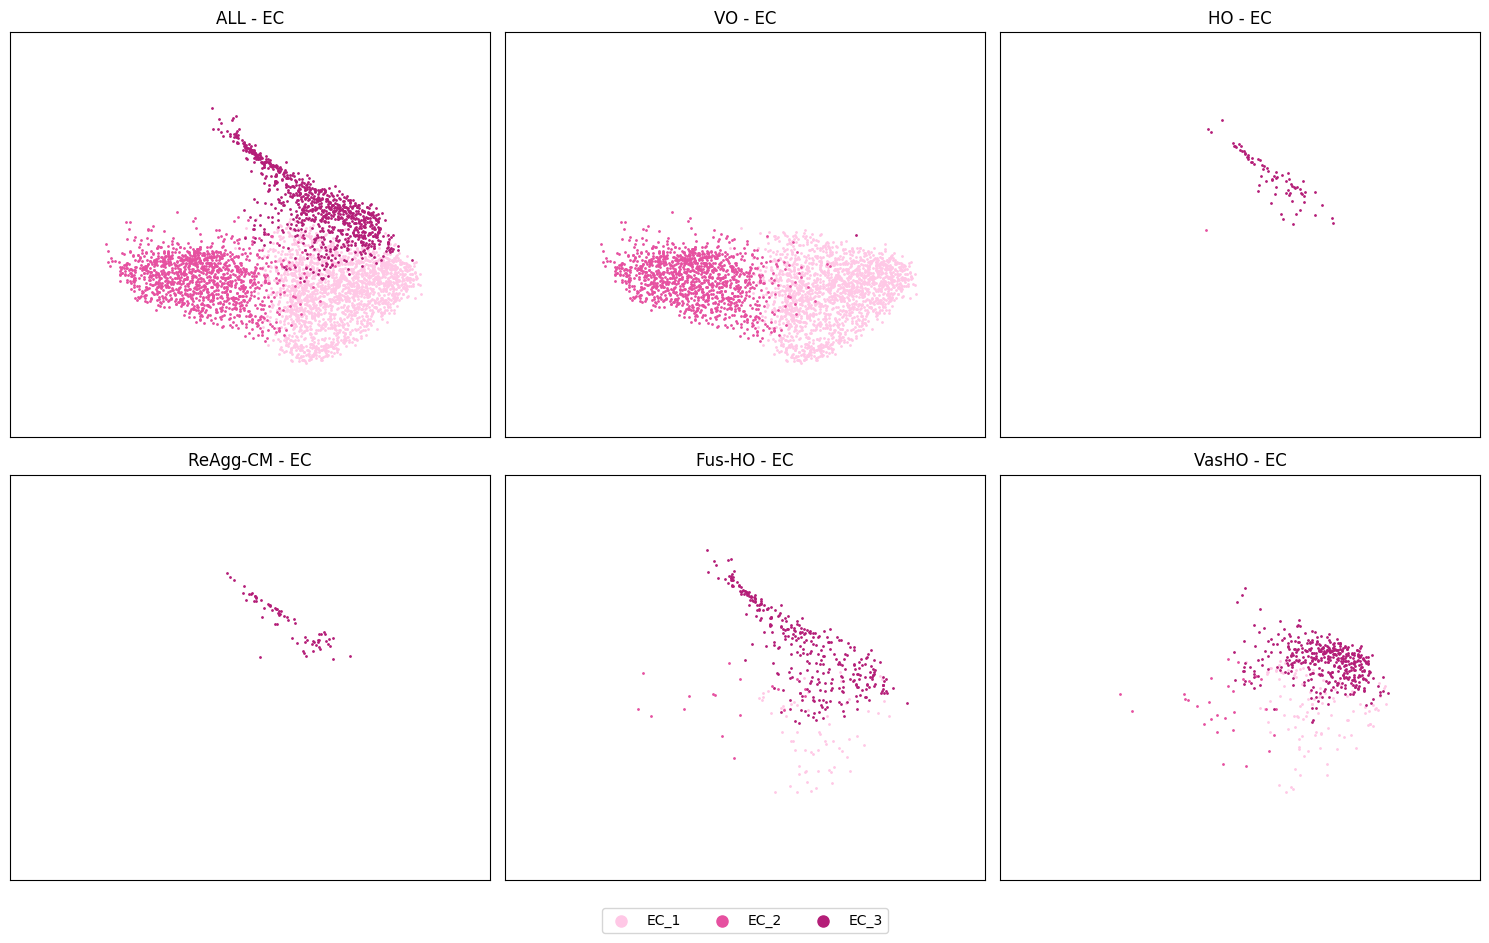

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([2, 8])
    ax.set_ylim([-6, 3])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

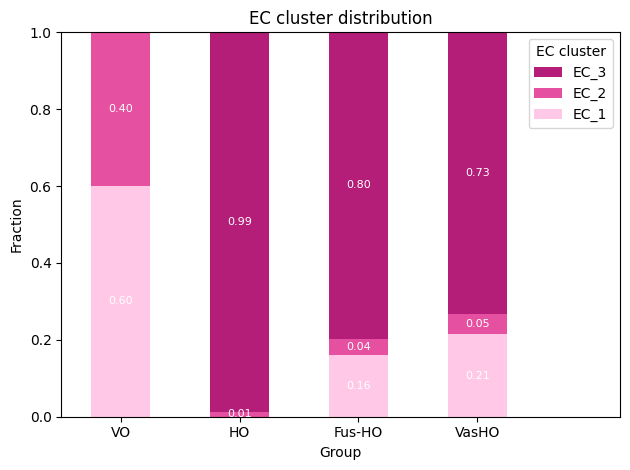

In [27]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'ReAgg-CM':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

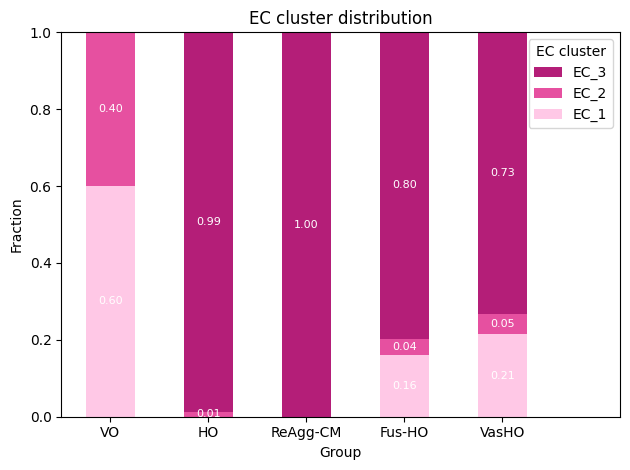

In [28]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

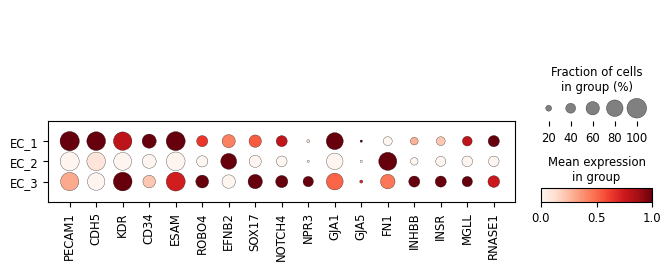

In [29]:
marker_dict = ['PECAM1', 'CDH5', 'KDR', 'CD34', 'ESAM','ROBO4','EFNB2', 'SOX17', 'NOTCH4', 
               'NPR3', 'GJA1','GJA5','FN1', 'INHBB', 'INSR', 'MGLL', 'RNASE1']

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", show=False)
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

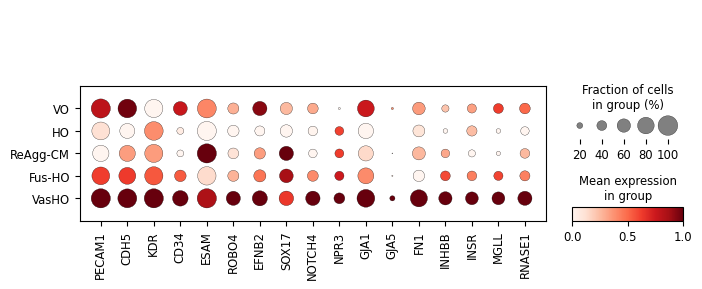

In [30]:
categories_order = samples.copy()
categories_order.remove("ALL")

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.3 PVSC

In [5]:
ct = "PVSC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

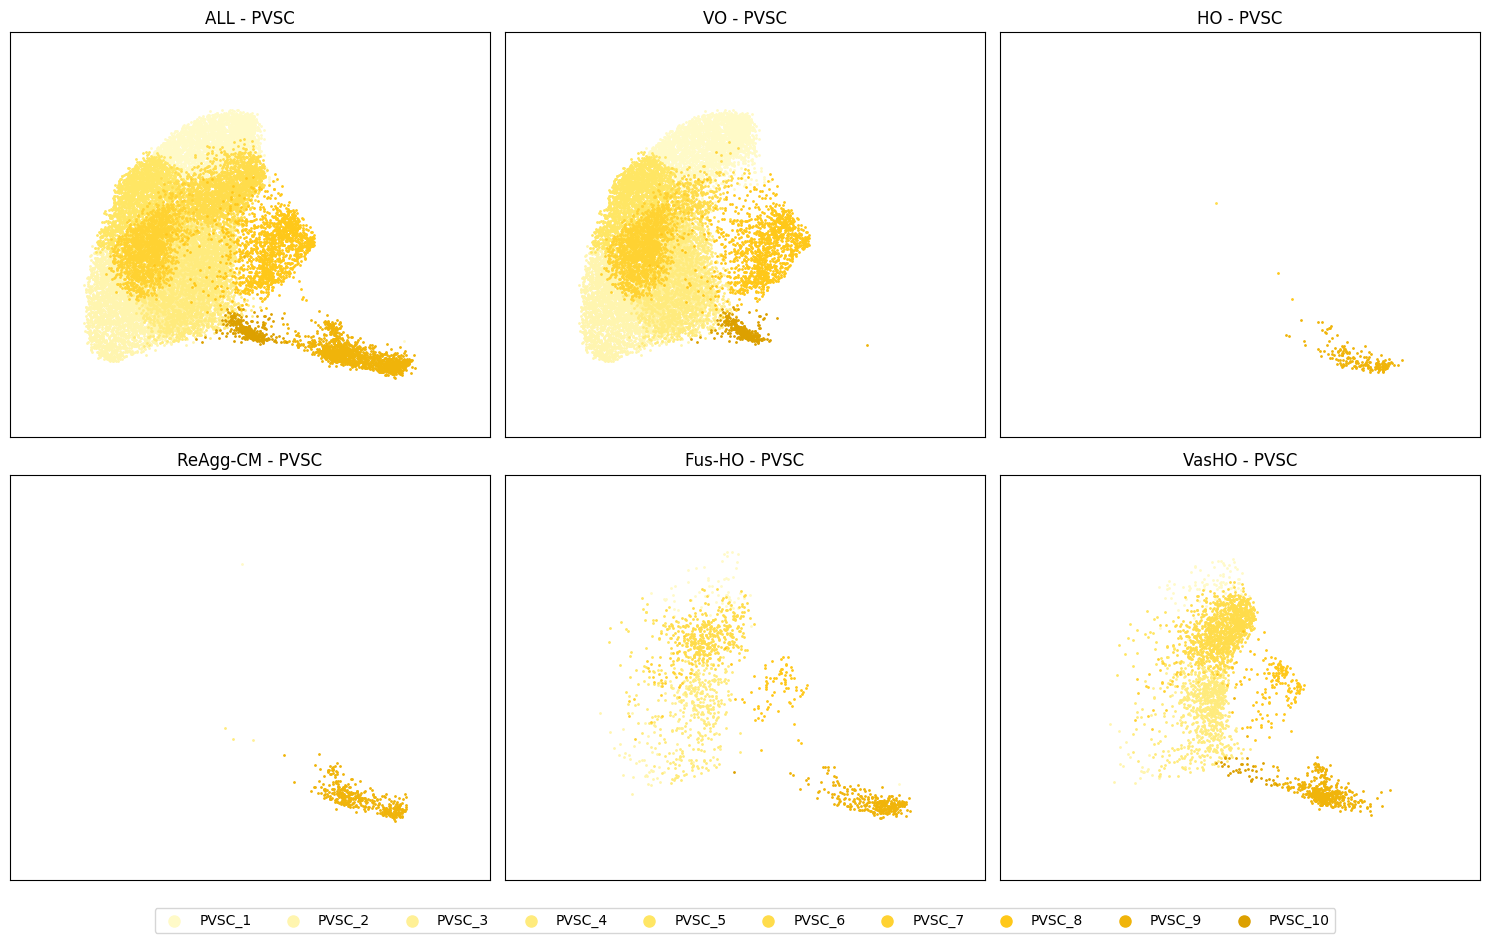

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in ("PVSC_1", "PVSC_2", "PVSC_3", "PVSC_4", "PVSC_5", "PVSC_6", "PVSC_7", "PVSC_8", "PVSC_9", "PVSC_10"):
    # for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([-12, 2])
    ax.set_ylim([3, 17])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=12,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

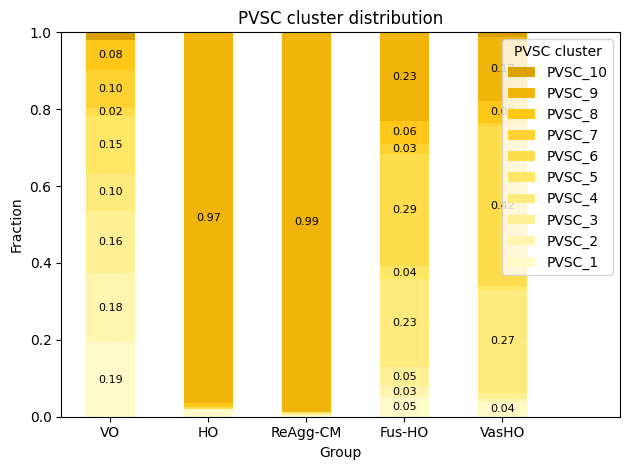

In [7]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T
df = df[["PVSC_1", "PVSC_2", "PVSC_3", "PVSC_4", "PVSC_5", "PVSC_6", "PVSC_7", "PVSC_8", "PVSC_9", "PVSC_10"]]

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

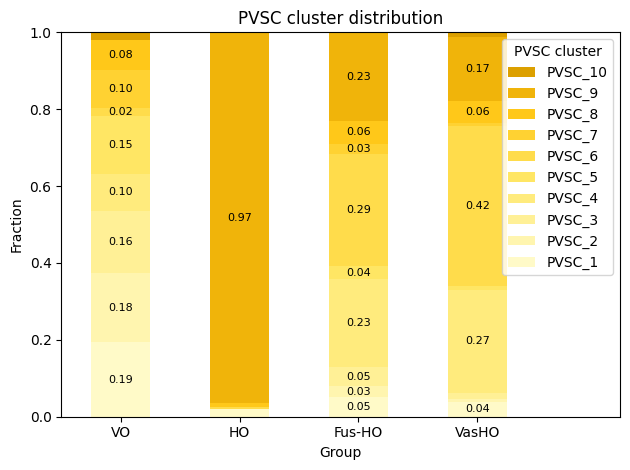

In [8]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == "ReAgg-CM":
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T
df = df[["PVSC_1", "PVSC_2", "PVSC_3", "PVSC_4", "PVSC_5", "PVSC_6", "PVSC_7", "PVSC_8", "PVSC_9", "PVSC_10"]]

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

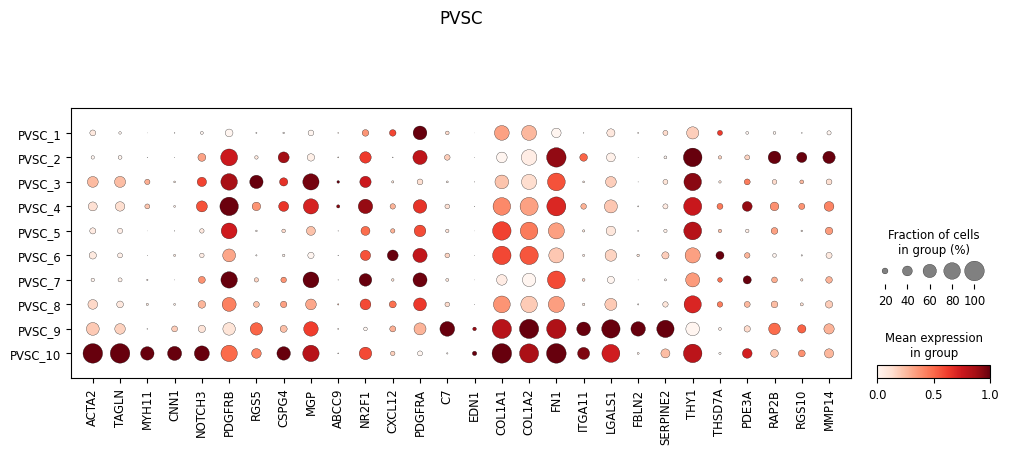

In [9]:
marker_dict = ["ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", 
               "MGP", "ABCC9", "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", 
               "COL1A2", "FN1", "ITGA11", "LGALS1", "FBLN2", "SERPINE2", "THY1", "THSD7A", "PDE3A", "RAP2B", "RGS10", "MMP14"]

categories_order = ['PVSC_1', 'PVSC_2', 'PVSC_3', 'PVSC_4', 'PVSC_5', 'PVSC_6', 'PVSC_7', 'PVSC_8', 'PVSC_9', 'PVSC_10']

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", title=ct, show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

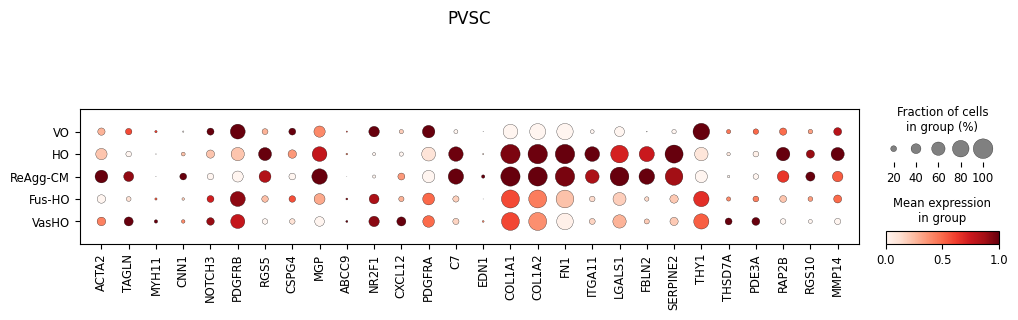

In [10]:
categories_order = samples.copy()
categories_order.remove("ALL")

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", title=ct, show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

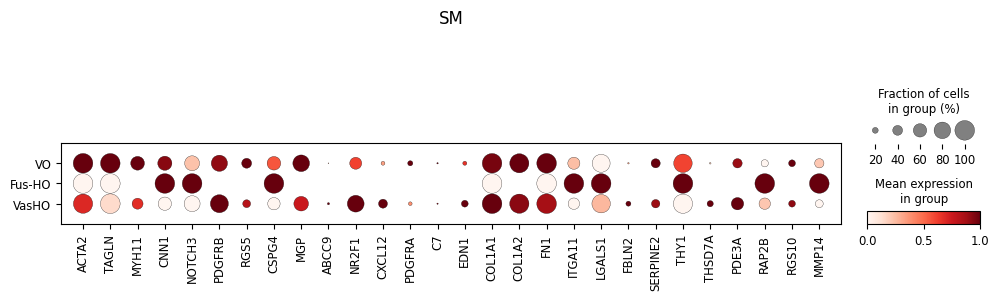

In [11]:
sc.pl.dotplot(adata[adata.obs["cpdb_group"] == "SM"], marker_dict, groupby="batch", standard_scale="var", title="SM", show=False, categories_order=["VO","Fus-HO","VasHO"])
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.SM.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.SM.svg', bbox_inches="tight")
plt.show()

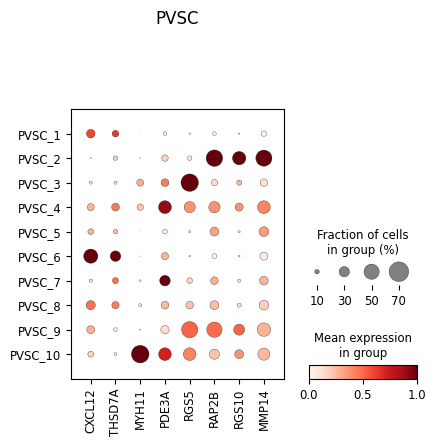

In [12]:
marker_dict = ["CXCL12", "THSD7A", "MYH11", "PDE3A", "RGS5", "RAP2B", "RGS10", "MMP14"]

categories_order = ['PVSC_1', 'PVSC_2', 'PVSC_3', 'PVSC_4', 'PVSC_5', 'PVSC_6', 'PVSC_7', 'PVSC_8', 'PVSC_9', 'PVSC_10']

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", title=ct, show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.additional.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.additional.svg', bbox_inches="tight")
plt.show()

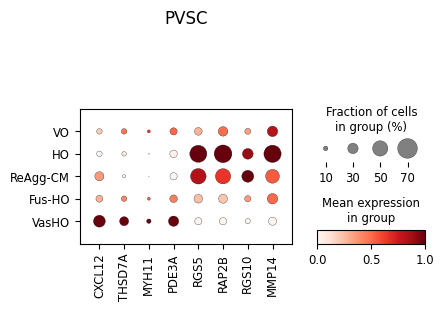

In [13]:
categories_order = samples.copy()
categories_order.remove("ALL")

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", title=ct, show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.additional.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.additional.svg', bbox_inches="tight")
plt.show()

## 2.4 recollect

In [38]:
adata_all = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/ALL.h5ad')

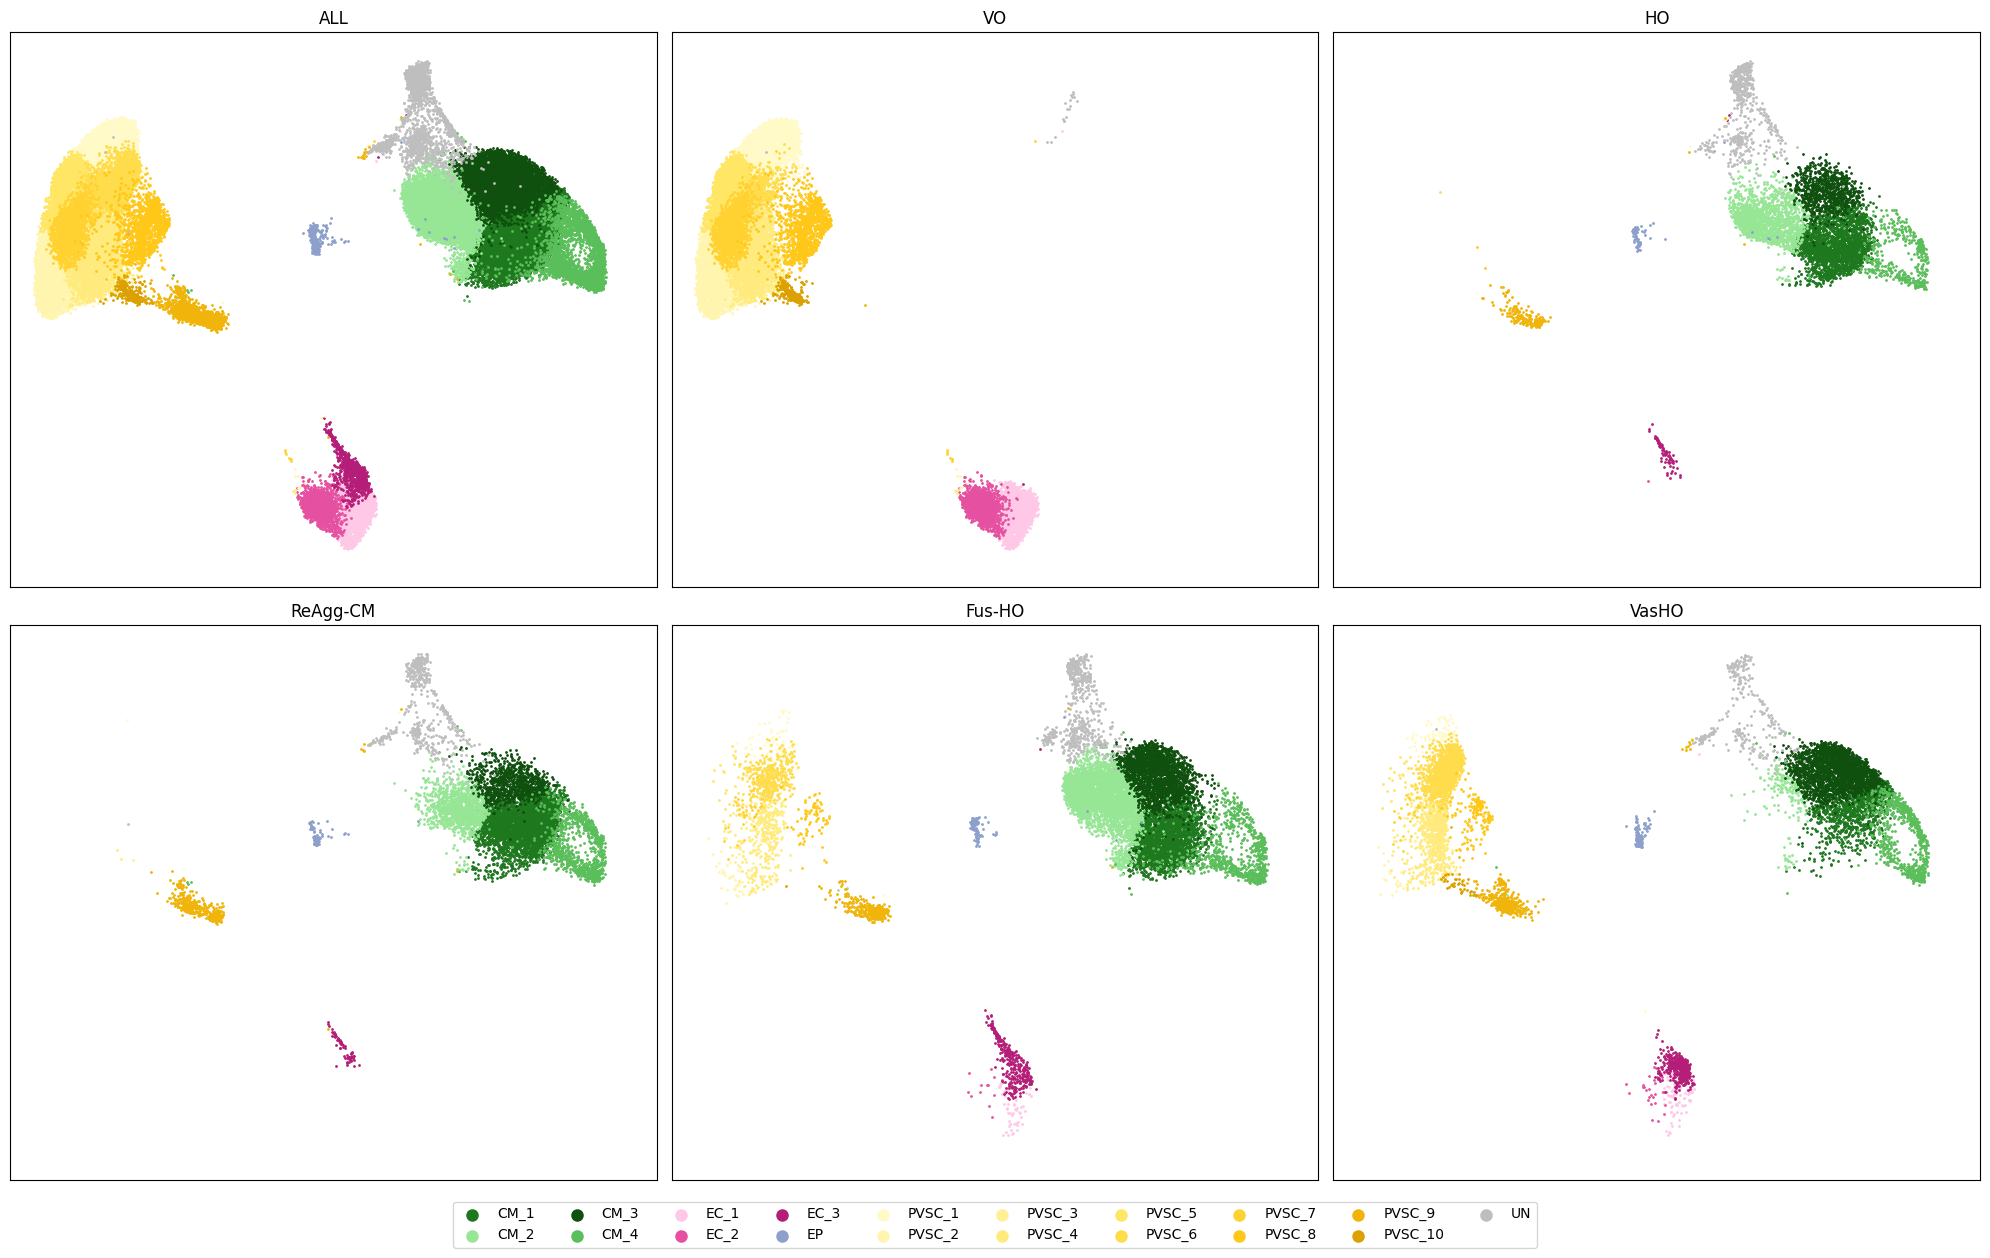

In [39]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):

    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    for j, cts in enumerate(adata_all.obs["cell_type_subcluster"].unique().sort_values()):
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=colormap_subclusters[cts], 
            s=1)
                
        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)

    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_label.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_label.complete.svg', bbox_inches="tight")
plt.show()

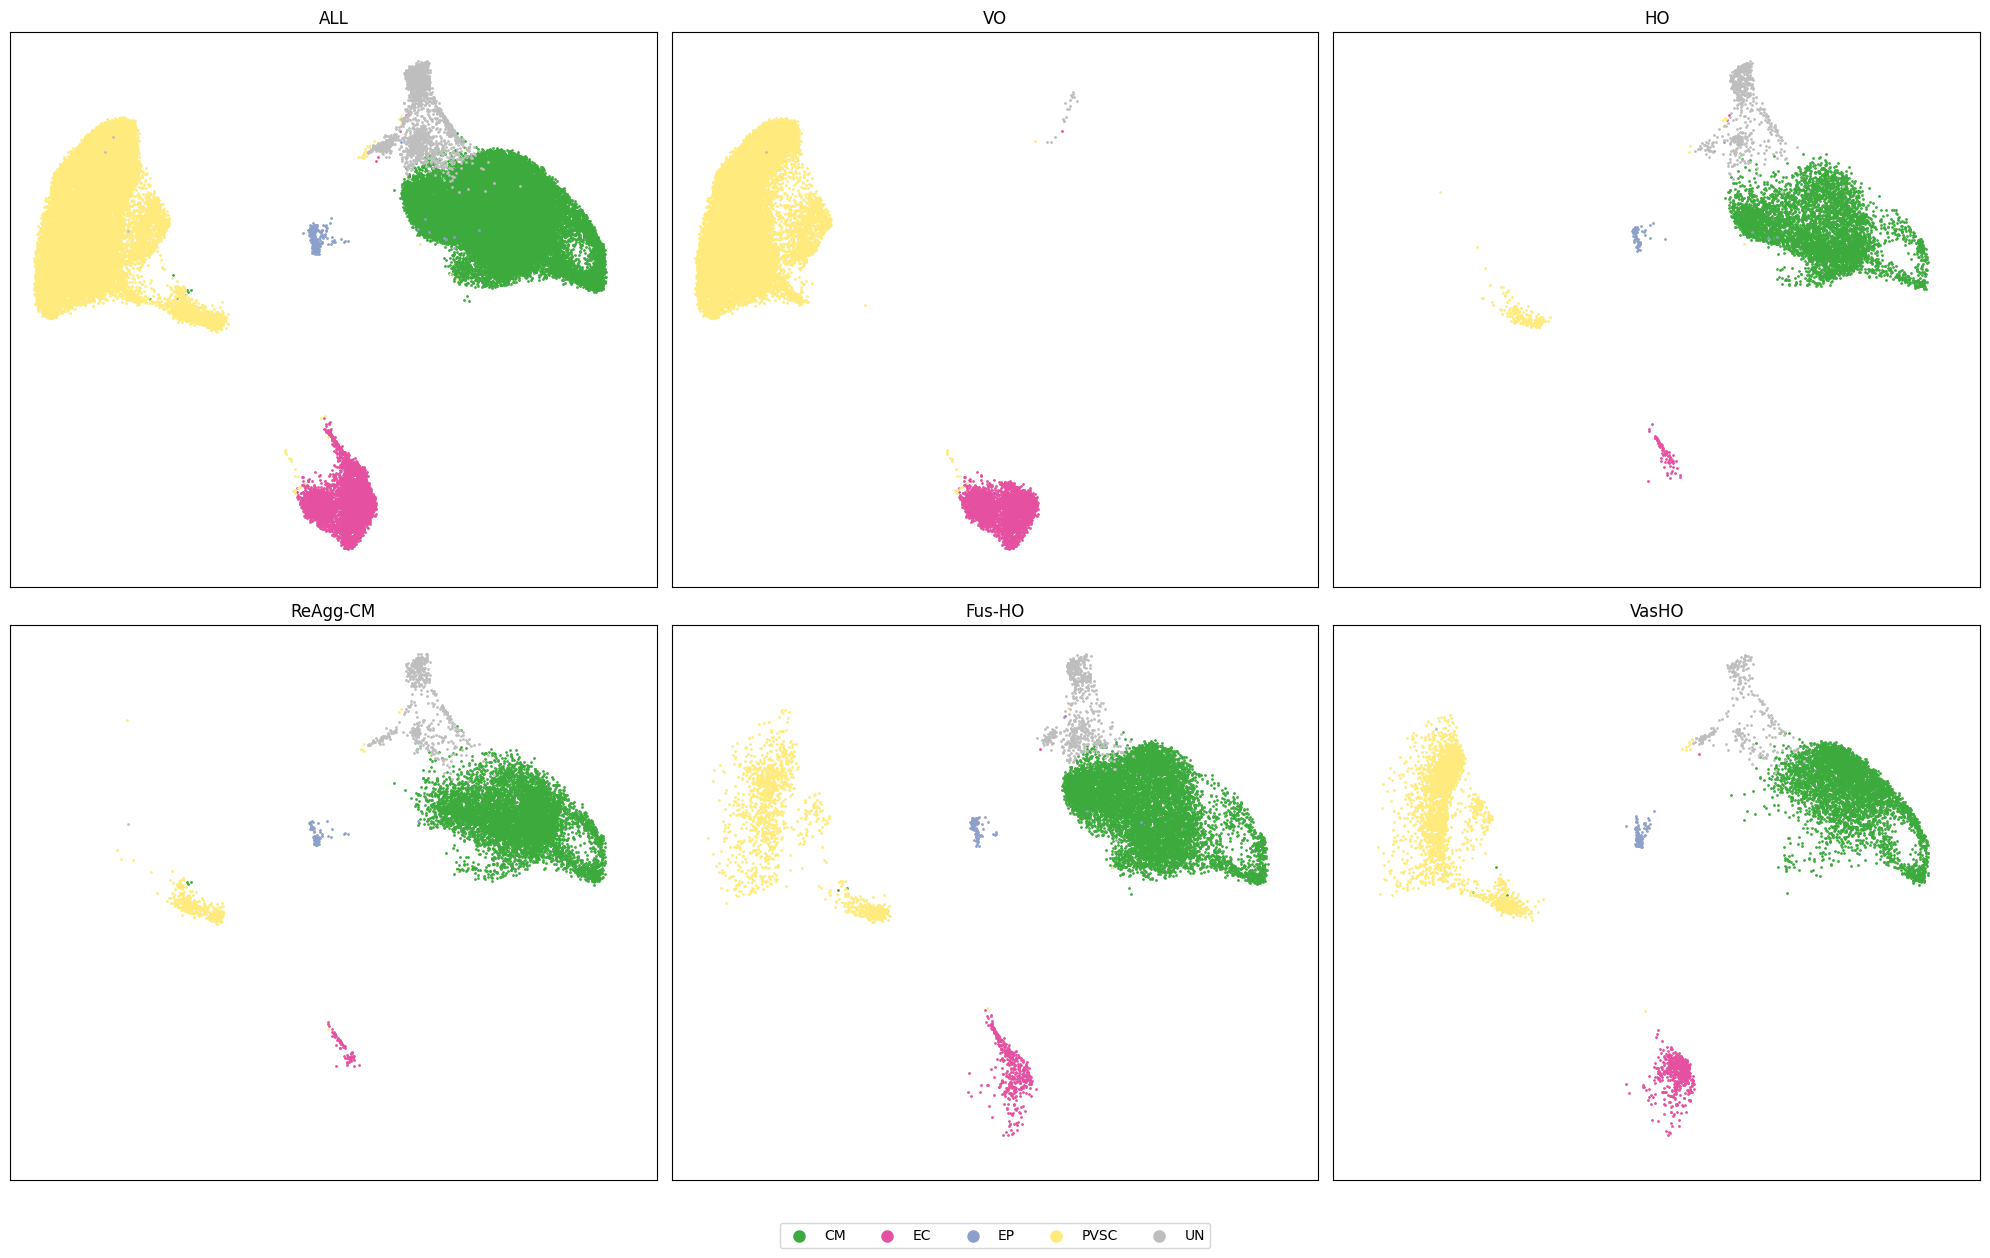

In [40]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):

    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    for j, cts in enumerate(adata_all.obs["cell_type"].unique().sort_values()):
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == cts, 1], 
            label=cts, 
            color=colormap_cpdb[cts], 
            s=1)
                
        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)

    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/cell_type.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/cell_type.complete.svg', bbox_inches="tight")
plt.show()

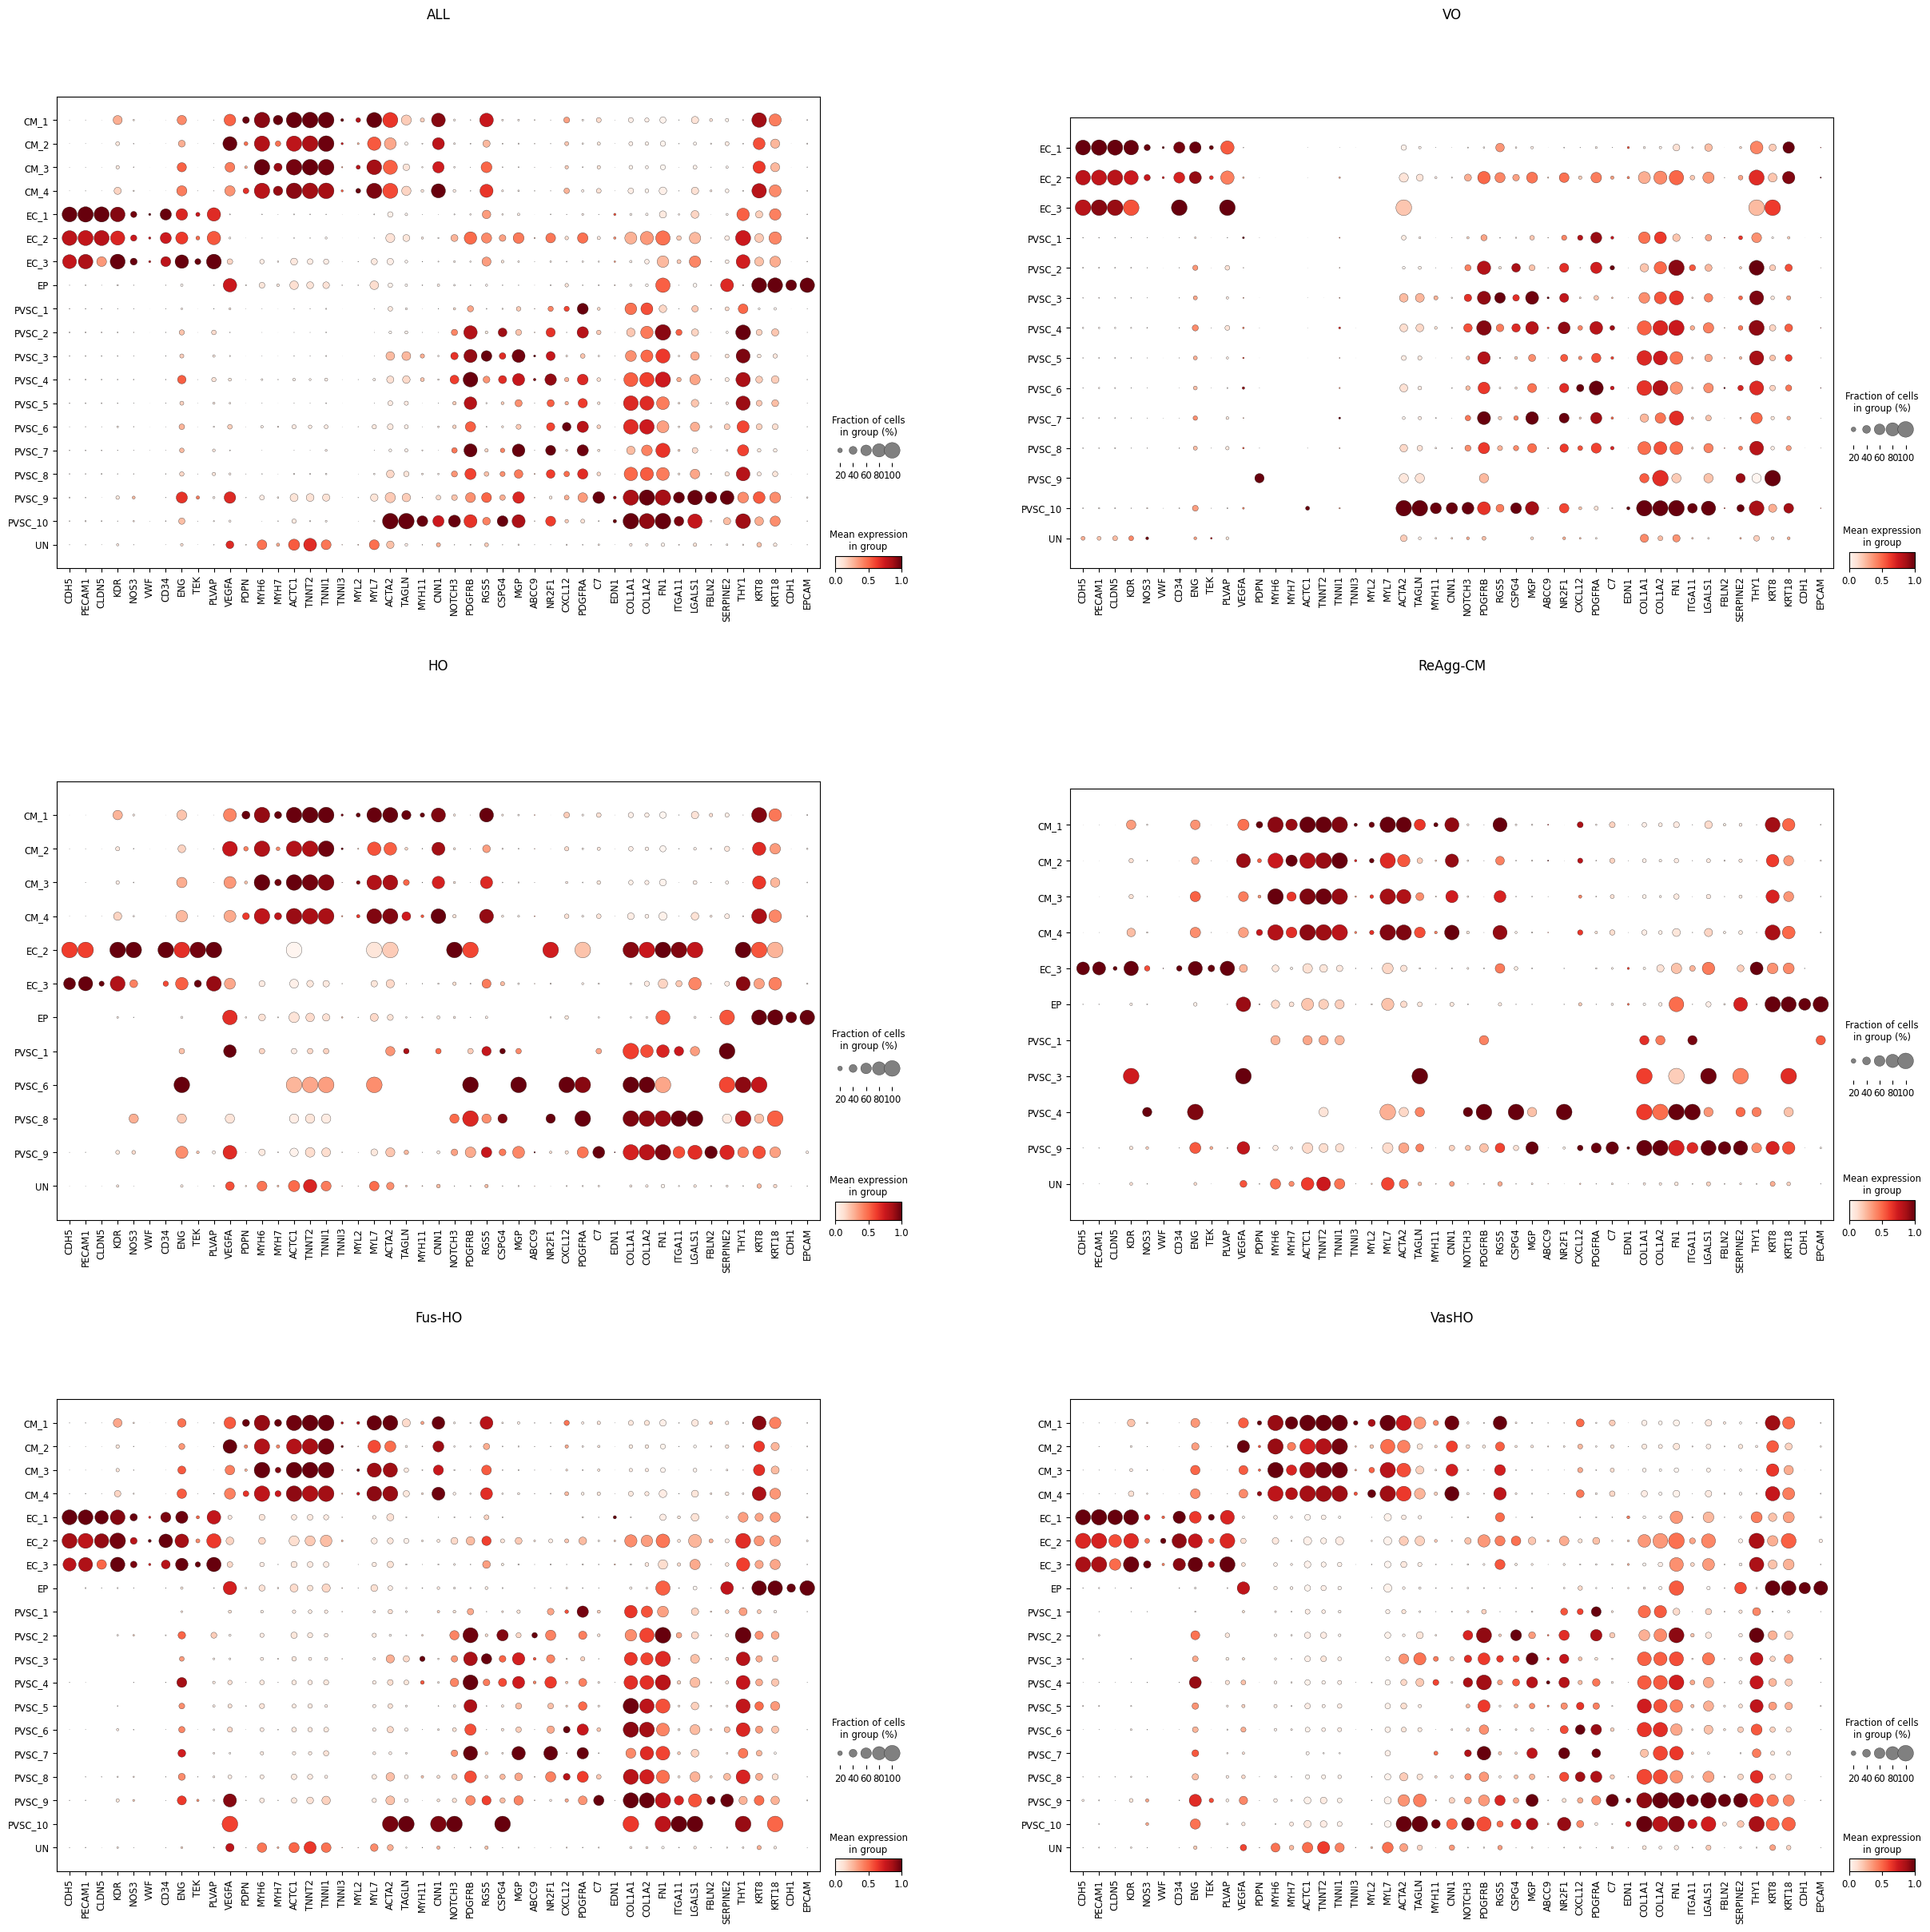

In [41]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample, show=False)
    
plt.savefig(f'{WORK_DIR}/dotplot/secondary_label.complete.png')
plt.savefig(f'{WORK_DIR}/dotplot/secondary_label.complete.svg')
plt.show()

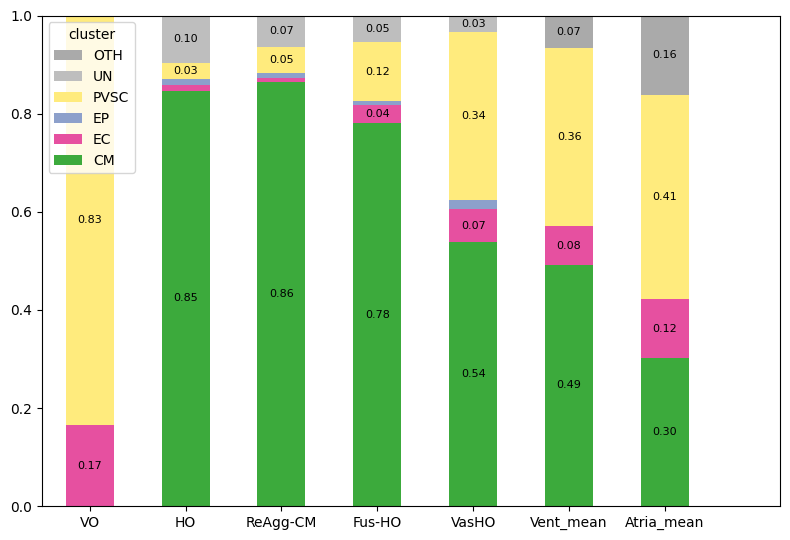

In [42]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cell_type'].value_counts())
    res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df.loc["OTH"] = 0

df["Vent_mean"] = df["VO"].copy()
df["Atria_mean"] = df["Vent_mean"].copy()

df.loc["CM", "Vent_mean"] = 49.2
df.loc["EC", "Vent_mean"] = 7.8
df.loc["EP", "Vent_mean"] = 0
df.loc["PVSC", "Vent_mean"] = 36.3
df.loc["UN", "Vent_mean"] = 0
df.loc["OTH", "Vent_mean"] = 6.7

df.loc["CM", "Atria_mean"] = 30.1
df.loc["EC", "Atria_mean"] = 12.2
df.loc["EP", "Atria_mean"] = 0
df.loc["PVSC", "Atria_mean"] = 41.4
df.loc["UN", "Atria_mean"] = 0
df.loc["OTH", "Atria_mean"] = 16.3

df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, color=[colormap_cpdb[col] for col in df.columns], ax=ax)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 7.2))
plt.xticks(rotation=0)
# plt.title("Celltype distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/cell_type_wCA.complete_extra.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/cell_type_wCA.complete_extra.svg', bbox_inches="tight")
plt.show()

# 3. DE

# 4. scVelo

# 5. Label transfer

In [17]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
import anndata as ad

In [18]:
os.system(f"mkdir -p {WORK_DIR}/label_transfer")

0

## 5.2 CM

In [57]:
adata = sc.read_h5ad(f"{WORK_DIR}/label_transfer/heart_cell_atlas_v2/GSE216019_Adult_Foetal_Integrated_Hearts_VKS2022.h5ad")
adata_source = sc.pp.subsample(adata, n_obs=1000, random_state=42, copy=True)

adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")
adata_target = adata[adata.obs["cell_type"] == "CM"]

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [58]:
common_genes = adata_source.var_names.intersection(adata_target.var_names)
common_genes = common_genes.intersection(['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 
               'HOPX', 'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SCN5A', 'SLC8A1', 
               'ACADL', 'CORIN'])
adata_source = adata_source[:, common_genes].copy()
adata_target = adata_target[:, common_genes].copy()

In [59]:
adata_source.obs["is_source"] = True
adata_source.obs["cell_type_subcluster"] = "None"
adata_source.obs["batch"] = "None"
adata_target.obs["is_source"] = False
adata_target.obs["stage"] = "Unknown"

adata_all = ad.concat([adata_source, adata_target])
sc.pp.combat(adata_all, key="is_source")
adata_all.obsm.clear()
sc.pp.pca(adata_all, n_comps=20)

adata_source = adata_all[adata_all.obs["is_source"] == True]
adata_target = adata_all[adata_all.obs["is_source"] == False]

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [60]:
adata = adata_all.copy()

adata.obs["group"] = None

# assign labels
adata.obs.loc[adata.obs["is_source"] == True, "group"] = \
    adata.obs.loc[adata.obs["is_source"] == True, "stage"]

# adata.obs.loc[adata.obs["is_source"] == False, "group"] = \
#     adata.obs.loc[adata.obs["is_source"] == False, "cell_type_subcluster"]
adata.obs.loc[adata.obs["is_source"] == False, "group"] = \
    adata.obs.loc[adata.obs["is_source"] == False, "batch"]

In [61]:
# groups = ["foetal", "adult", "CM_1", "CM_2", "CM_3", "CM_4"]
groups = ["foetal", "adult", 'HO', 'ReAgg_CM', 'Fus_HO', 'VasHO']

In [62]:
rep_key = "X_pca"

group_data = {}
for g in groups:
    subset = adata[adata.obs["group"] == g]
    group_data[g] = subset.obsm[rep_key]

In [63]:
import numpy as np

def sample_distance(X1, X2, n_pairs=1000, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    idx1 = rng.integers(0, X1.shape[0], size=n_pairs)
    idx2 = rng.integers(0, X2.shape[0], size=n_pairs)

    dists = np.linalg.norm(X1[idx1] - X2[idx2], axis=1)
    return dists.mean()

In [64]:
rng = np.random.default_rng(0)

n = len(groups)
dist_matrix = np.zeros((n, n))

for i, g1 in enumerate(groups):
    for j, g2 in enumerate(groups):
        dist = sample_distance(
            group_data[g1],
            group_data[g2],
            n_pairs=1000,
            rng=rng
        )
        dist_matrix[i, j] = dist

In [65]:
import pandas as pd

df_dist = pd.DataFrame(dist_matrix, index=groups, columns=groups)

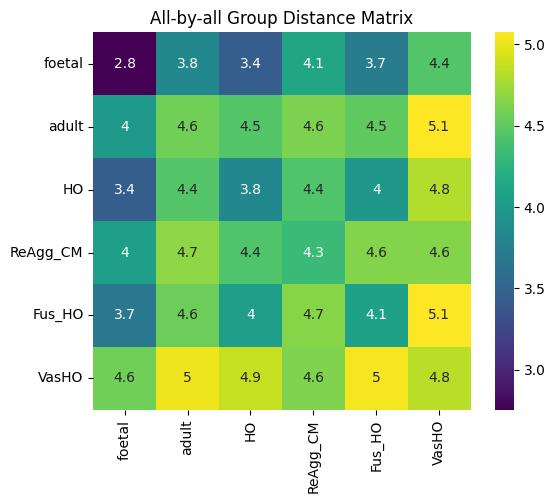

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(df_dist, annot=True, cmap="viridis", square=True)
plt.title("All-by-all Group Distance Matrix")
plt.tight_layout()
plt.show()

# 6. CellPhoneDB

In [1]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import ktplotspy as kpy
import seaborn as sns
import matplotlib.pyplot as plt

import glob
from tqdm import tqdm

from cellphonedb.src.core.methods import cpdb_analysis_method,cpdb_statistical_analysis_method

In [2]:
base_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO10"

cpdb_path = "/home/brett/work/Cell2CellCommunication/cpdb/database/v5.0.0/cellphonedb.zip"
work_dir  = f"{base_dir}/cpdb"
data_dir  = f"{base_dir}/cpdb/adata"
processed_dir = f"{base_dir}/cpdb/processed"
figs_dir = f"{base_dir}/cpdb/figs"

In [4]:
os.system(f"mkdir -p {data_dir}; mkdir -p {processed_dir}; mkdir -p {figs_dir}")

0

## 6.1 prepare data

In [5]:
adata_full = sc.read_h5ad(f"{base_dir}/adata/sample_recollect/ALL.h5ad")

sc.pp.highly_variable_genes(adata_full, n_top_genes=4000)

for batch in adata_full.obs["batch"].unique():
    adata_full[adata_full.obs['batch'] == batch].write(f"{work_dir}/adata/{batch}.h5ad")

## 6.2 run CPDB

In [7]:
pattern = os.path.join(data_dir,"*.h5ad")
for adata_path in glob.glob(pattern):
    # if ("/HO.h5ad" not in adata_path) and ("/VCO.h5ad" not in adata_path):
    #     continue
    print(adata_path)

    label = os.path.basename(adata_path).split(".")[0]
    adata = sc.read_h5ad(adata_path)
    adata = adata[:,adata.var['highly_variable']]
    updated_adata_path = os.path.join(processed_dir,os.path.basename(adata_path.replace(".h5ad",".hvg.h5ad")))
    adata.write(updated_adata_path,compression="gzip")

    metadata_df = pd.DataFrame({
        "barcode_sample" : adata.obs_names,
        "cell_type"      : adata.obs['cpdb_group'].to_list()
    })

    metadata_df.index = np.arange(metadata_df.shape[0])
    metadata_path     = os.path.join(work_dir,f"{label}.statistical.metadata.tsv")
    metadata_df.to_csv(metadata_path,index=False,sep="\t")

    out_dir      = os.path.join(work_dir,f"{label}.statistical")
    # Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
    cpdb_results = cpdb_statistical_analysis_method.call(
        cpdb_file_path     = cpdb_path,         # mandatory: CellphoneDB database zip file.
        meta_file_path     = metadata_path,     # mandatory: tsv file defining barcodes to cell label.
        counts_file_path   = updated_adata_path,# mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
        counts_data        = 'gene_name',       # defines the gene annotation in counts matrix.
        score_interactions = True,              # optional: whether to score interactions or not. 
        output_path        = out_dir,           # Path to save results
        pvalue             = 0.05
    )

/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/adata/VO.h5ad
Reading user files...
The following user files were loaded successfully:
/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/processed/VO.hvg.h5ad
/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/VO.statistical.metadata.tsv
[ ][CORE][11/04/26-06:23:11][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
[ ][CORE][11/04/26-06:23:12][INFO] Running Real Analysis
[ ][CORE][11/04/26-06:23:12][INFO] Running Statistical Analysis


100%|██████████████████████████████████████████████████| 1000/1000 [00:26<00:00, 38.10it/s]


[ ][CORE][11/04/26-06:23:39][INFO] Building Pvalues result
[ ][CORE][11/04/26-06:23:39][INFO] Building results
[ ][CORE][11/04/26-06:23:39][INFO] Scoring interactions: Filtering genes per cell type..


100%|████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 57.69it/s]

[ ][CORE][11/04/26-06:23:40][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..


...

[ ][CORE][11/04/26-06:24:33][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|███████████████████████████████████████████████████████| 6/6 [00:00<00:00, 644.60it/s]


[ ][CORE][11/04/26-06:24:33][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|█████████████████████████████████████████████████████| 36/36 [00:00<00:00, 148.10it/s]


Saved deconvoluted to /home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/HO.statistical/statistical_analysis_deconvoluted_04_11_2026_062433.txt
Saved deconvoluted_percents to /home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/HO.statistical/statistical_analysis_deconvoluted_percents_04_11_2026_062433.txt
Saved means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/HO.statistical/statistical_analysis_means_04_11_2026_062433.txt
Saved pvalues to /home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/HO.statistical/statistical_analysis_pvalues_04_11_2026_062433.txt
Saved significant_means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/HO.statistical/statistical_analysis_significant_means_04_11_2026_062433.txt
Saved interaction_scores to /home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/HO.statistical/statistical_analysis_interaction_scores_04_11_2026_062433.txt


In [10]:
pattern = os.path.join(work_dir,"*.statistical")
date = "04_11_2026"
for cpdb_dir in glob.glob(pattern):
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    means_path         = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_means_{date}_*.txt"))[0]
    pvals_path         = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_pvalues_{date}_*.txt"))[0]
    deconvolution_path = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_deconvoluted_{date}_*.txt"))[0]
    interaction_path   = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_interaction_scores_{date}_*.txt"))[0]

    means_df         = pd.read_csv(means_path,sep="\t")
    pvals_df         = pd.read_csv(pvals_path,sep="\t")
    deconvolution_df = pd.read_csv(deconvolution_path,sep="\t")
    interaction_df   = pd.read_csv(interaction_path,sep="\t")

    adata_path = os.path.join(data_dir,f"{label}.h5ad")
    adata      = ad.read_h5ad(adata_path)
    adata.obs["cpdb_key"] = adata.obs["cpdb_group"]
    # adata.obs["cpdb_key"] = adata.obs["cell_type"]

    for cpdb_key in tqdm(adata.obs["cpdb_key"].unique(),desc=label):
        df = kpy.plot_cpdb(
            adata=adata,
            cell_type1=cpdb_key,
            cell_type2=".",
            means=means_df,
            pvals=pvals_df,
            celltype_key="cpdb_key",
            highlight_size=1,
            figsize=(24,24),
            title=f"{label} {cpdb_key}",
            default_style=False,
            return_table=True
        )
        df.index = [index.replace(">@<","-") for index in df.index]
        df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
        df["significant"] = df["significant"].fillna("no")
        df_path = os.path.join(cpdb_dir,f"{label}__{cpdb_key}.csv")
        df.to_csv(df_path)

VasHO: 100%|█████████████████████████████████████████████████| 7/7 [00:02<00:00,  2.86it/s]


In [12]:
from plotnine import scale_color_identity, scale_fill_identity
from plotnine import scale_color_manual
    
pattern = os.path.join(work_dir, "*.statistical")
for cpdb_dir in glob.glob(pattern):
    print(cpdb_dir)
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    means_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_means_{date}_*.txt")[0], sep='\t')
    pvals_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t')
    decon_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_deconvoluted_{date}_*.txt")[0], sep='\t')
    adata = sc.read_h5ad(f"{work_dir}/adata/{label}.h5ad")

    out = kpy.plot_cpdb_heatmap(
        pvals=pvals_df,
        symmetrical=False,
        return_tables=True
    )

    g = sns.clustermap(out["count_network"],annot=True,fmt='g',cbar=False,figsize=(6,6),cbar_pos=None,)
    g.ax_col_dendrogram.remove()
    g.ax_heatmap.set_title(f"Number of significant interactions: {label}")
    fig_path = f"{figs_dir}/{label}.n_signif_interactions_heatmap.png"
    plt.savefig(fig_path,dpi=100)
    plt.close()

    df = kpy.plot_cpdb(
        adata=adata,
        cell_type1=".",
        cell_type2=".",
        means=means_df,
        pvals=pvals_df,
        celltype_key="cpdb_group",
        highlight_size=1,
        figsize=(6,6),
        title=f"{label}",
        default_style=False,
        return_table=True
    )
    df.index = [index.replace(">@<","-") for index in df.index]
    df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
    df["significant"] = df["significant"].fillna("no")
    df = df[df["significant"] == "yes"]
    df_path = f"{figs_dir}/{label}.csv"
    df.to_csv(df_path)

    p = kpy.plot_cpdb(
        adata=adata,
        cell_type1=".",
        cell_type2=".",
        keep_significant_only=True,
        means=means_df,
        pvals=pvals_df,
        celltype_key="cpdb_group",
        figsize=(20, 8),
        title=f"{label}: active interactions",
        return_table=False
    )
    p.save(f"{figs_dir}/{label}.dotplot.png")

    cts = adata.obs["cpdb_group"].unique().to_list()
    cts.remove("UN")
    # if np.nan in cts:
    #     cts.remove(np.nan)

    sector_colors = {
        "CM": (60/255, 170/255, 60/255),
        "EC": (230/255, 80/255, 160/255),
        "EP": (60/255, 180/255, 220/255),
        "PR": (255/255, 235/255, 125/255),
        "FB": (240/255, 180/255, 20/255),
        "SM": (220/255, 160/255, 30/255),
        "UN": (190/255, 190/255, 190/255),
        "OTH": (170/255, 170/255, 170/255),
    }

    p = kpy.plot_cpdb_chord(
        adata=adata[adata.obs["cpdb_group"] != "UN"],
        cell_type1='.',
        cell_type2='.',
        keep_celltypes=cts,
        means=means_df,
        pvals=pvals_df,
        deconvoluted=decon_df,
        celltype_key="cpdb_group",
        link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
        sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
        legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
        link_offset=1,
        sector_colors=sector_colors
    )

    plt.savefig(f"{figs_dir}/{label}.chordplot.png")
    plt.close()

/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/Fus-HO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/VO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/HO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/ReAgg-CM.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO10/cpdb/VasHO.statistical
